1. Klasifikasi masing-masing katewi Ftynn alasannya:
• Operasi arr + arr pada NumPy array
• program python biasa (tanpa threading/muttigyocessing) yang membaca file Lalu b" demi b"
• yang masing•masing menialankan simulasi cuaca untuk wilayah secara independen



*   arr + arr pada NumPy arrayKlasifikasi: SIMD
Alasan: operasi penjumlahan array adalah operasi vektor/elemen-per elemen satu operasi aritmetika (addition) diaplikasikan ke banyak elemen data sekaligus. Secara implementasi berada di level C/C pada CPU dapat memakai instruksi vektor (SSE/AVX) sehingga cocok digolongkan SIMD.
Catatan: pada beberapa build/implementasi NumPy ada optimisasi multi-threaded di level C, tetapi model pemrogramannya tetap vektor (single instruction applied to many data).
*   Program Python biasa (tanpa threading/multiprocessing) yang membaca file lalu memproses baris demi baris
Klasifikasi: SISD
Alasan: eksekusi berjalan sekuensial: satu instruksi interpreter mengeksekusi satu langkah pada satu data (mis. baca satu baris proses  lanjut baris berikut). Tidak ada paralelisme instruksi atau data di model program ini.



*   Cluster komputer di mana masing-masing node menjalankan simulasi cuaca berbeda untuk wilayah berbeda secara independen. Klasifikasi, MIMD
Alasan, tiap node menjalankan (bisa) instruksi/program sendiri pada subset data (wilayahnya). Node berjalan independen banyak instruksi pada banyak data MIMD adalah tepat.


2. Analisis Sebuah aplikasi pervolahan Citra metniUki proporsi paraJel p 0.85.

• Hitung twritis untuk N = 2, 4.8, 16, 32, 64 (gunakan tungsi amdaht_speedup di atas)

• Buat plot speedup vs N

• pada N berapa penambahan prosescr mulai manfaat yang sangat kecil Cdiminishing returns')? Jelaskan alasan kalian.

Amdahl speedups (P = 0.85 ):


,N,speedup,speedup_rounded
0,1,1.000000,1.000000
1,2,1.739130,1.739130
2,4,2.758621,2.758621
3,8,3.902439,3.902439
4,16,4.923077,4.923077
5,32,5.663717,5.663717
6,64,6.124402,6.124402


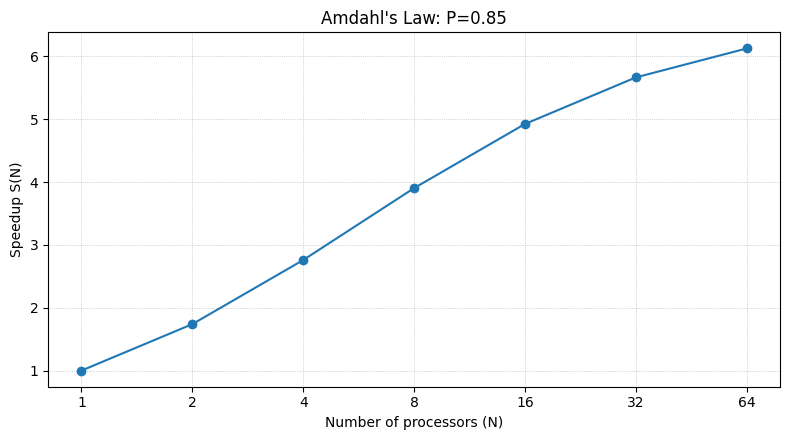

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

def amdahl_speedup(P, N):
    return 1.0 / ((1.0 - P) + P / N)

# Parameter
P = 0.85
Ns = [1, 2, 4, 8, 16, 32, 64]
speedups = [amdahl_speedup(P, N) for N in Ns]

# Tabel hasil
amdahl_df = pd.DataFrame({'N': Ns, 'speedup': speedups})
amdahl_df['speedup_rounded'] = amdahl_df['speedup'].round(6)
print('Amdahl speedups (P =', P, '):')
display(amdahl_df)

# Plot
plt.figure(figsize=(8,4.5))
plt.plot(amdahl_df['N'], amdahl_df['speedup'], marker='o')
plt.xscale('log', base=2)
plt.xticks(Ns, labels=Ns)
plt.xlabel('Number of processors (N)')
plt.ylabel('Speedup S(N)')
plt.title(f"Amdahl's Law: P={P}")
plt.grid(True, linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()

Program Python ini untuk menghitung dan memvisualisasikan Amdahl’s Law, yaitu hukum yang menjelaskan seberapa besar peningkatan kecepatan (speedup) suatu program ketika dijalankan secara paralel dengan beberapa prosesor. Di awal, program mengimpor beberapa library seperti math, pandas, dan matplotlib.pyplot untuk perhitungan, pengolahan data, serta pembuatan grafik. Kemudian didefinisikan fungsi amdahl_speedup(P, N) yang menghitung speedup berdasarkan rumus Amdahl, yaitu S(N)=1/(1-P)+P/N, di mana P adalah proporsi program yang bisa diparalelkan dan N adalah jumlah prosesor.

Selanjutnya, program menetapkan nilai P = 0.85 (artinya 85% program bisa diparalelkan) dan daftar jumlah prosesor Ns = [1, 2, 4, 8, 16, 32, 64]. Dengan menggunakan list comprehension, program menghitung nilai speedup untuk setiap jumlah prosesor tersebut dan menyimpannya dalam list speedups. Hasil perhitungan ini kemudian dimasukkan ke dalam sebuah DataFrame pandas dengan dua kolom, yaitu jumlah prosesor (N) dan nilai speedup (speedup).

Berdasarkan hasil perhitungan dan grafik, peningkatan speedup signifikan terjadi hingga sekitar N = 8–16. Setelah itu, penambahan prosesor hanya memberikan peningkatan kecil. Hal ini menunjukkan terjadinya diminishing returns, yang disebabkan oleh bagian program yang tidak dapat diparalelkan (15%). Oleh karena itu, penggunaan lebih dari 16 prosesor menjadi kurang efisien.

3. Benchmark mandiri: Ambil salah satu fungsi CPU-bound buatan sendiri modifikasi hitung_prima , atau "fungsi lain seperti menghitung
deret Fibonacci naif secara rekursif). ukur Waktu eksekusinya untuk minimal 4 ukuran input berbeda menggunakan time.pref_counter dan
timeit . latu bandingkan hasil keduanya dalam Satu tabeL/plot

In [2]:
import time
import timeit

# Fungsi CPU-bound: Fibonacci rekursif
def fib(n):
    if n <= 1:
        return n
    return fib(n-1) + fib(n-2)

# Input yang diuji (minimal 4)
inputs = [20, 25, 30, 32]

print("=== Benchmark time.perf_counter() ===")
for n in inputs:
    start = time.perf_counter()
    fib(n)
    end = time.perf_counter()
    print(f"fib({n}) -> waktu: {end - start:.6f} detik")

print("\n=== Benchmark timeit ===")
for n in inputs:
    t = timeit.timeit(lambda: fib(n), number=1)
    print(f"fib({n}) -> waktu: {t:.6f} detik")

=== Benchmark time.perf_counter() ===
fib(20) -> waktu: 0.001581 detik
fib(25) -> waktu: 0.020054 detik
fib(30) -> waktu: 0.214373 detik
fib(32) -> waktu: 0.506233 detik

=== Benchmark timeit ===
fib(20) -> waktu: 0.001633 detik
fib(25) -> waktu: 0.018015 detik
fib(30) -> waktu: 0.508746 detik
fib(32) -> waktu: 0.635105 detik


Pada percobaan ini digunakan fungsi Fibonacci rekursif sebagai contoh proses CPU-bound, yaitu proses yang kinerjanya sangat bergantung pada kemampuan prosesor. Fungsi rekursif dipilih karena memiliki kompleksitas waktu yang tinggi (≈ O(2ⁿ)), sehingga cocok untuk menguji performa eksekusi program.

Pengujian dilakukan menggunakan dua metode, yaitu time.perf_counter() dan timeit, dengan beberapa variasi input (n = 20, 25, 30, 32).

Dari hasil pengujian, terlihat bahwa waktu eksekusi meningkat secara signifikan seiring bertambahnya nilai input. Misalnya, perbedaan waktu antara fib(20) dan fib(30) sangat jauh, meskipun selisih input hanya 10. Hal ini disebabkan oleh sifat rekursif yang melakukan banyak perhitungan berulang, sehingga beban CPU meningkat drastis.

4. Refleksi singkat (maks. 150 kata): Menurut kalian, kapan Hukum Amdahl lebih relevan digunakan dibandingkan Hukum Guftafson, dan sebaliknya?
Berikan Satu Contoh kasus nyata untuk masing-masing

Hukum Amdahl lebih relevan ketika ukuran masalah tetap (fixed workload), karena menunjukkan batas maksimum percepatan akibat bagian program yang tidak dapat diparalelkan. Contohnya adalah aplikasi desktop seperti pengolahan gambar

Hukum Gustafson lebih cocok ketika ukuran masalah dapat diperbesar (scaled workload), sehingga penambahan prosesor tetap memberikan manfaat signifikan. Contohnya adalah komputasi big data